# Diamond Price Prediction

This notebook walks through:
1. Loading the diamond dataset  
2. Feature engineering  
3. Ordinal-encoding of cut/color/clarity  
4. Building a RandomForest with log-target transform  
5. Hyperparameter tuning via successive halving  
6. Final evaluation and diagnostic plots


In [1]:
# 1) Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


In [2]:
file_path = "/Users/pbat/Projects/cmor438/data/diamond-prices.csv"
assert os.path.exists(file_path), f"File not found: {file_path}"
df = pd.read_csv(file_path)
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Feature engineering

- Compute `volume = x * y * z`  
- Compute `carat_depth_ratio = carat / depth`


In [3]:
df["volume"] = df["x"] * df["y"] * df["z"]
df["carat_depth_ratio"] = df["carat"] / df["depth"]
df[["carat","depth","volume","carat_depth_ratio"]].head()


,carat,depth,volume,carat_depth_ratio
0,0.23,61.5,38.202030,0.003740
1,0.21,59.8,34.505856,0.003512
2,0.23,56.9,38.076885,0.004042
3,0.29,62.4,46.724580,0.004647
4,0.31,63.3,51.917250,0.004897


In [4]:
## Prepare train / test split

NUM_FEATS = ["carat", "depth", "table", "x", "y", "z", "volume", "carat_depth_ratio"]
ORD_FEATS = ["cut", "color", "clarity"]
TARGET    = "price"

X = df[NUM_FEATS + ORD_FEATS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [5]:
## Build preprocessing pipeline with true‐order ordinal encoding

ordinal_categories = [
    ["Fair","Good","Very Good","Premium","Ideal"],           # cut
    ["J","I","H","G","F","E","D"],                          # color
    ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]       # clarity
]

ord_enc = OrdinalEncoder(
    categories=ordinal_categories,
    dtype=int,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATS),
    ("ord", ord_enc, ORD_FEATS),
])


In [6]:
## Wrap in log-transform regressor + set up halving grid search

base_pipe = Pipeline([
    ("pre", preprocessor),
    ("rf", RandomForestRegressor(random_state=42))
])

ttr = TransformedTargetRegressor(
    regressor=base_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

param_grid = {
    "regressor__rf__n_estimators": [50, 100],
    "regressor__rf__max_depth":    [10, 20, None],
    "regressor__rf__min_samples_split": [2, 5, 10],
}

search = HalvingGridSearchCV(
    ttr,
    param_grid,
    factor=3,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

print("🔍 Running HalvingGridSearchCV…")
search.fit(X_train, y_train)
print("Best hyperparameters:", search.best_params_)


🔍 Running HalvingGridSearchCV…
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 4444
max_resources_: 40000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 18
n_resources: 4444
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END regressor__rf__max_depth=10, regressor__rf__min_samples_split=2, regressor__rf__n_estimators=50; total time=   0.4s
[CV] END regressor__rf__max_depth=10, regressor__rf__min_samples_split=5, regressor__rf__n_estimators=50; total time=   0.4s
[CV] END regressor__rf__max_depth=10, regressor__rf__min_samples_split=2, regressor__rf__n_estimators=50; total time=   0.4s
[CV] END regressor__rf__max_depth=10, regressor__rf__min_samples_split=5, regressor__rf__n_estimators=50; total time=   0.4s
[CV] END regressor__rf__max_depth=10, regressor__rf__min_samples_split=2, regressor__rf__n_estimators=50; total time=   0.4s
[CV] END regressor__rf__max_depth=10, regressor__rf__min_samples_split=5, regres

In [7]:
## Final evaluation on hold-out set
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"\nFinal performance on test set:")
print(f"  MAE   : ${mae:,.2f}")
print(f"  RMSE  : ${rmse:,.2f}")
print(f"  R²    : {r2:.4f}")
print(f"  MAPE  : {100*mape:.2f}%")



Final performance on test set:
  MAE   : $262.28
  RMSE  : $524.32
  R²    : 0.9822
  MAPE  : 6.34%


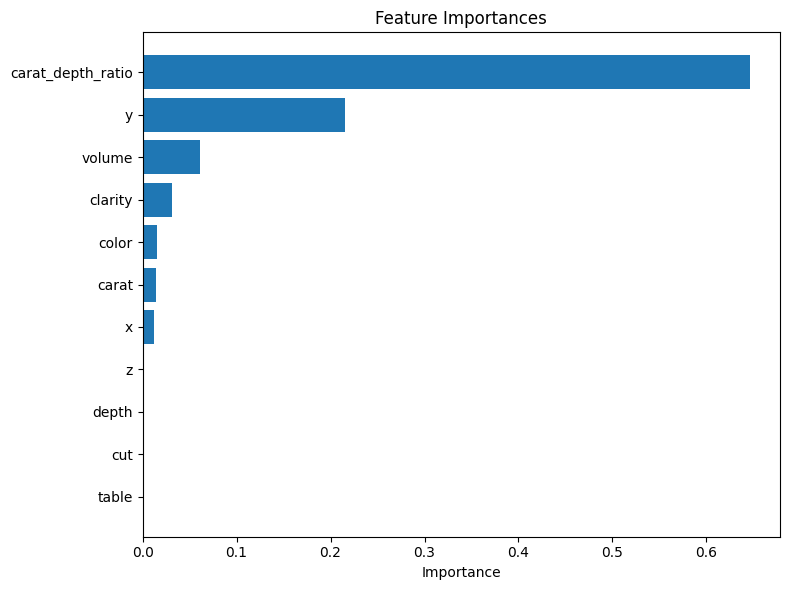

In [8]:
## Diagnostic plots
# 1) Feature importances
rf = best_model.regressor_.named_steps["rf"]
feat_names = NUM_FEATS + ORD_FEATS
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh([feat_names[i] for i in indices], importances[indices])
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


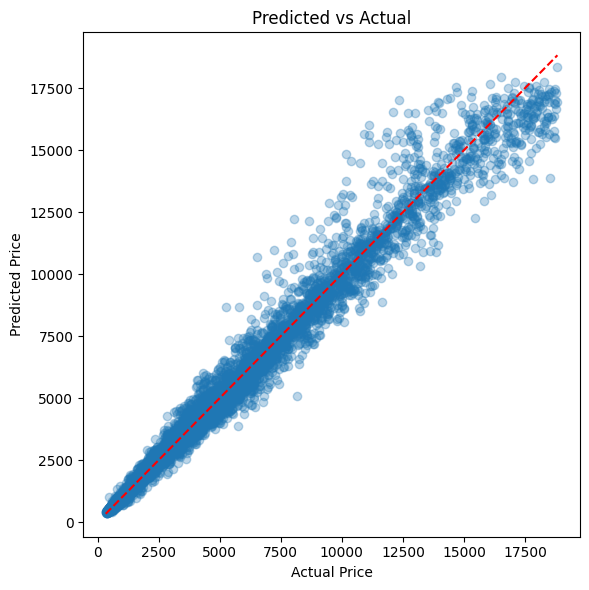

In [9]:
# 2) Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()


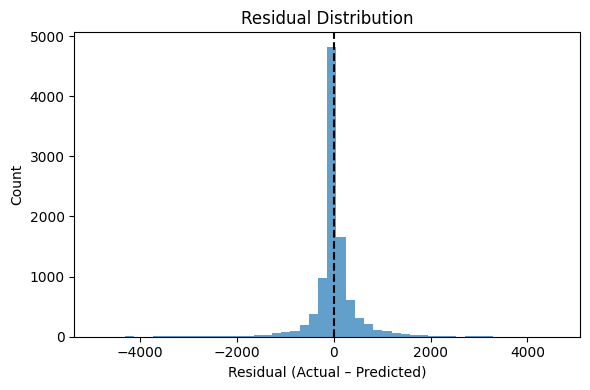

In [10]:
# 3) Residual distribution
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50, alpha=0.7)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Residual (Actual – Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()
